In [1]:
import joblib
import pandas as pd

model = joblib.load("../models/late_delivery_model.pkl")
features = joblib.load("../models/model_features.pkl")

In [2]:
orders = [

# 1 — Normal low-risk order
{
"Order Item Quantity": 2,
"Sales": 120,
"Product Price": 60,
"Shipping Mode": "Standard Class",
"Order Region": "Western Europe",
"Order Country": "Germany",
"Customer Segment": "Consumer",
"Days for shipment (scheduled)": 4,
"Demand_Spike_Flag": 0,
"High_Demand_Risk_Flag": 0,
"Logistics_Load_Score": 0.2,
"logistics_pressure": 3,
"region_order_density": 2,
"month": 3,
"day_of_week": 2
},

# 2 — Same order but Express shipping
{
"Order Item Quantity": 2,
"Sales": 120,
"Product Price": 60,
"Shipping Mode": "Express",
"Order Region": "Western Europe",
"Order Country": "Germany",
"Customer Segment": "Consumer",
"Days for shipment (scheduled)": 2,
"Demand_Spike_Flag": 0,
"High_Demand_Risk_Flag": 0,
"Logistics_Load_Score": 0.2,
"logistics_pressure": 3,
"region_order_density": 2,
"month": 3,
"day_of_week": 2
},

# 3 — Heavy logistics load
{
"Order Item Quantity": 10,
"Sales": 900,
"Product Price": 90,
"Shipping Mode": "Standard Class",
"Order Region": "South Asia",
"Order Country": "India",
"Customer Segment": "Corporate",
"Days for shipment (scheduled)": 5,
"Demand_Spike_Flag": 1,
"High_Demand_Risk_Flag": 1,
"Logistics_Load_Score": 0.8,
"logistics_pressure": 60,
"region_order_density": 7,
"month": 11,
"day_of_week": 5
},

# 4 — Same heavy load but Express
{
"Order Item Quantity": 10,
"Sales": 900,
"Product Price": 90,
"Shipping Mode": "Express",
"Order Region": "South Asia",
"Order Country": "India",
"Customer Segment": "Corporate",
"Days for shipment (scheduled)": 2,
"Demand_Spike_Flag": 1,
"High_Demand_Risk_Flag": 1,
"Logistics_Load_Score": 0.8,
"logistics_pressure": 60,
"region_order_density": 7,
"month": 11,
"day_of_week": 5
},

# 5 — Holiday demand spike
{
"Order Item Quantity": 15,
"Sales": 1500,
"Product Price": 100,
"Shipping Mode": "Second Class",
"Order Region": "Central America",
"Order Country": "Mexico",
"Customer Segment": "Consumer",
"Days for shipment (scheduled)": 6,
"Demand_Spike_Flag": 1,
"High_Demand_Risk_Flag": 1,
"Logistics_Load_Score": 0.9,
"logistics_pressure": 80,
"region_order_density": 9,
"month": 12,
"day_of_week": 6
},

# 6 — Small urgent order
{
"Order Item Quantity": 1,
"Sales": 40,
"Product Price": 40,
"Shipping Mode": "Same Day",
"Order Region": "Oceania",
"Order Country": "Australia",
"Customer Segment": "Home Office",
"Days for shipment (scheduled)": 1,
"Demand_Spike_Flag": 0,
"High_Demand_Risk_Flag": 0,
"Logistics_Load_Score": 0.3,
"logistics_pressure": 4,
"region_order_density": 2,
"month": 7,
"day_of_week": 1
},

# 7 — High order density region
{
"Order Item Quantity": 8,
"Sales": 500,
"Product Price": 60,
"Shipping Mode": "Standard Class",
"Order Region": "Western Europe",
"Order Country": "France",
"Customer Segment": "Corporate",
"Days for shipment (scheduled)": 4,
"Demand_Spike_Flag": 0,
"High_Demand_Risk_Flag": 0,
"Logistics_Load_Score": 0.6,
"logistics_pressure": 25,
"region_order_density": 8,
"month": 9,
"day_of_week": 3
},

# 8 — Extreme stress scenario
{
"Order Item Quantity": 20,
"Sales": 2000,
"Product Price": 100,
"Shipping Mode": "Standard Class",
"Order Region": "South Asia",
"Order Country": "India",
"Customer Segment": "Consumer",
"Days for shipment (scheduled)": 7,
"Demand_Spike_Flag": 1,
"High_Demand_Risk_Flag": 1,
"Logistics_Load_Score": 0.95,
"logistics_pressure": 100,
"region_order_density": 10,
"month": 12,
"day_of_week": 5
}

]

In [3]:
input_df = pd.DataFrame(orders)

In [4]:
input_df = pd.get_dummies(input_df)

In [5]:
input_df = input_df.reindex(columns=features, fill_value=0)

In [6]:
predictions = model.predict(input_df)
probabilities = model.predict_proba(input_df)[:,1]

results = input_df.copy()

results["Predicted_Delay"] = predictions
results["Delay_Probability"] = probabilities

print(results[["Predicted_Delay", "Delay_Probability"]])

   Predicted_Delay  Delay_Probability
0                0           0.293150
1                1           0.768496
2                0           0.294502
3                1           0.843466
4                0           0.371077
5                1           0.786895
6                0           0.299396
7                0           0.219660


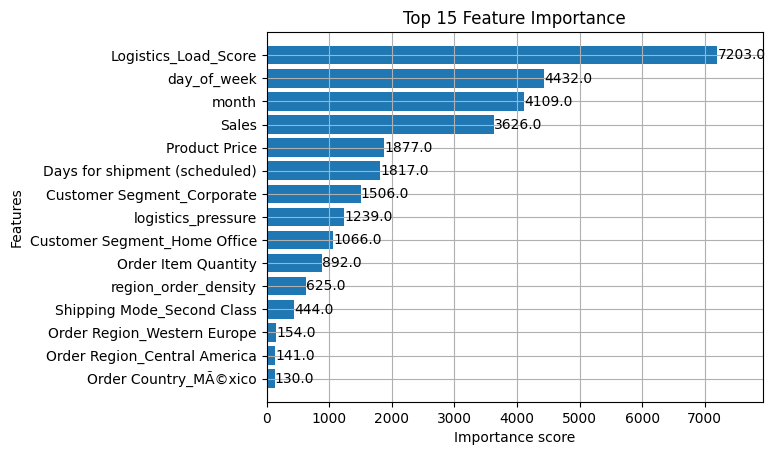

In [8]:
import xgboost as xgb
import matplotlib.pyplot as plt

xgb.plot_importance(
    model,
    max_num_features=15,
    height=0.8
)

plt.title("Top 15 Feature Importance")
plt.show()

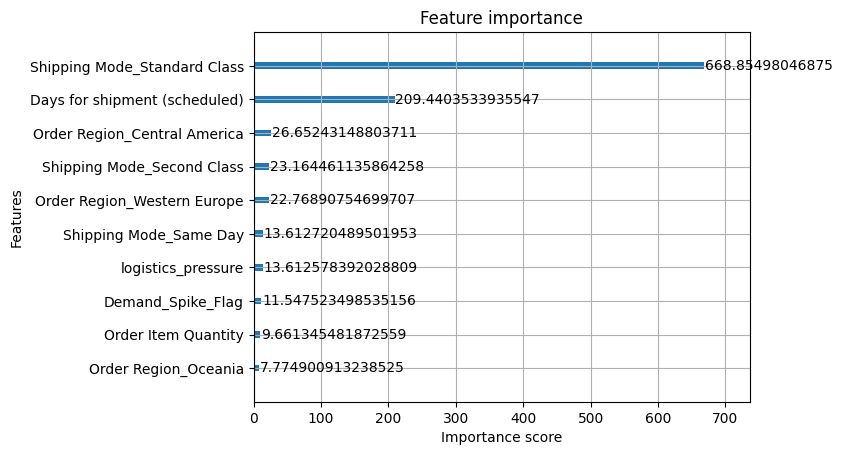

In [9]:
import xgboost as xgb

xgb.plot_importance(
    model,
    importance_type="gain",
    max_num_features=10
)
plt.show()